In [1]:
import pandas as pd

In [12]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

In [13]:
df = pd.read_csv(
    "../data/raw/twcs/twcs.csv",
    nrows=10000
)

In [14]:
df = df[df["inbound"] == True]

In [15]:
df = df[["text"]]

## Text Preprocessing

Before classification, we'll clean the text by:
- Converting to lowercase
- Removing special characters and extra whitespace
- Removing URLs and mentions
- Tokenizing into words

In [16]:
def clean_text(text):
    """Improved text cleaning preserving readability for NLP preprocessing."""
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove emoji and special unicode characters (but preserve apostrophes)
    text = ''.join(char if ord(char) < 128 or char == "'" else '' for char in text)
    
    # Remove URLs - replace with space to avoid word concatenation
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # Remove @mentions and #hashtags - replace with space to preserve word boundaries
    text = re.sub(r'@\w+|#\w+', ' ', text)
    
    # Remove quotes and special punctuation (but keep apostrophes for contractions)
    text = re.sub(r'["""\'''""]', '', text)  # Remove quote variations
    text = re.sub(r'[!?;:,\-—–]', ' ', text)  # Replace punctuation with spaces
    
    # Remove other special characters except apostrophes
    text = re.sub(r'[^a-z0-9\s\']', '', text)
    
    # Fix repeated characters (meeeeee -> me, yooooo -> yo)
    text = re.sub(r'([a-z])\1{2,}', r'\1', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to create clean_text column
df["clean_text"] = df["text"].apply(clean_text)

print(f"Created clean_text column with {len(df)} messages")
print(f"Average text length: {df['text'].str.len().mean():.0f} characters")
print(f"Average clean text length: {df['clean_text'].str.len().mean():.0f} characters")

Created clean_text column with 5503 messages
Average text length: 104 characters
Average clean text length: 78 characters


In [17]:
df.head(10)

,text,clean_text
1,@sprintcare and how do you propose we do that,and how do you propose we do that
2,@sprintcare I have sent several private messag...,i have sent several private messages and no on...
4,@sprintcare I did.,i did
6,@sprintcare is the worst customer service,is the worst customer service
8,@sprintcare You gonna magically change your co...,you gonna magically change your connectivity f...
10,@sprintcare Since I signed up with you....Sinc...,since i signed up with yousince day 1
12,@115714 y’all lie about your “great” connectio...,yall lie about your great connection 5 bars lt...
14,"@115714 whenever I contact customer support, t...",whenever i contact customer support they tell ...
16,@Ask_Spectrum Would you like me to email you a...,would you like me to email you a copy of one s...
18,@Ask_Spectrum I received this from your corpor...,i received this from your corporate office wou...


In [18]:
def assign_intent(text):

    text = str(text).lower()

    # =========================
    # COMPLAINT
    # =========================
    if any(word in text for word in [

        "worst",
        "bad",
        "terrible",
        "awful",
        "hate",
        "angry",
        "annoying",
        "ridiculous",
        "garbage",
        "sucks",
        "suck",
        "bullshit",
        "wtf",
        "frustrated",
        "not happy",
        "disappointed",
        "unacceptable",
        "horrible",
        "epic fail",
        "shame",
        "useless",
        "shit",
        "crap",
        "discriminatory",
        "fake news",
        "stupid",
        "idiots",
        "lied",
        "lie",
        "broken service",
        "poor service"

    ]):
        return "complaint"


    # =========================
    # REFUND
    # =========================
    elif any(word in text for word in [

        "refund",
        "money back",
        "refunded",
        "refund me",
        "cancel my reservation",
        "return my money",
        "delivery charge"

    ]):
        return "refund_request"


    # =========================
    # DELIVERY
    # =========================
    elif any(word in text for word in [

        "delivery",
        "delivered",
        "shipment",
        "shipping",
        "package",
        "tracking",
        "arrive",
        "arrived",
        "late",
        "driver",
        "out for delivery",
        "wrong country",
        "not delivered",
        "pickup order"

    ]):
        return "delivery_issue"


    # =========================
    # TECHNICAL SUPPORT
    # =========================
    elif any(word in text for word in [

        "error",
        "bug",
        "issue",
        "problem",
        "not working",
        "doesn't work",
        "doesnt work",
        "crash",
        "crashed",
        "freeze",
        "stuck",
        "wifi",
        "internet",
        "app",
        "ios",
        "battery",
        "screen",
        "sync",
        "loading",
        "connection",
        "connectivity",
        "broken link",
        "404",
        "update",
        "diagnostic",
        "technical",
        "router",
        "slow",
        "lag",
        "service going"

    ]):
        return "technical_support"


    # =========================
    # PAYMENT
    # =========================
    elif any(word in text for word in [

        "payment",
        "pay",
        "paid",
        "charged",
        "credit card",
        "bill",
        "balance",
        "bank",
        "money",
        "verify payment",
        "double charged",
        "charged twice"

    ]):
        return "payment_issue"


    # =========================
    # ACCOUNT
    # =========================
    elif any(word in text for word in [

        "account",
        "login",
        "log in",
        "password",
        "sign in",
        "verify",
        "locked",
        "unlock",
        "cannot validate",
        "can't log in",
        "cant log in",
        "account takeover"

    ]):
        return "account_problem"


    # =========================
    # POSITIVE FEEDBACK
    # =========================
    elif any(word in text for word in [

        "thank you",
        "thanks",
        "great",
        "awesome",
        "love",
        "helped",
        "appreciate",
        "best",
        "quick action",
        "fixed",
        "helpful",
        "resolved",
        "fan for life",
        "cheers"

    ]):
        return "positive_feedback"


    # =========================
    # DEFAULT
    # =========================
    else:
        return "general_question"

In [19]:
df["intent"] = df["text"].apply(assign_intent)

In [20]:
df.head(20)

,text,clean_text,intent
1,@sprintcare and how do you propose we do that,and how do you propose we do that,general_question
2,@sprintcare I have sent several private messag...,i have sent several private messages and no on...,general_question
4,@sprintcare I did.,i did,general_question
6,@sprintcare is the worst customer service,is the worst customer service,complaint
8,@sprintcare You gonna magically change your co...,you gonna magically change your connectivity f...,technical_support
10,@sprintcare Since I signed up with you....Sinc...,since i signed up with yousince day 1,general_question
12,@115714 y’all lie about your “great” connectio...,yall lie about your great connection 5 bars lt...,complaint
14,"@115714 whenever I contact customer support, t...",whenever i contact customer support they tell ...,account_problem
16,@Ask_Spectrum Would you like me to email you a...,would you like me to email you a copy of one s...,general_question
18,@Ask_Spectrum I received this from your corpor...,i received this from your corporate office wou...,general_question


In [21]:
import matplotlib.pyplot as plt

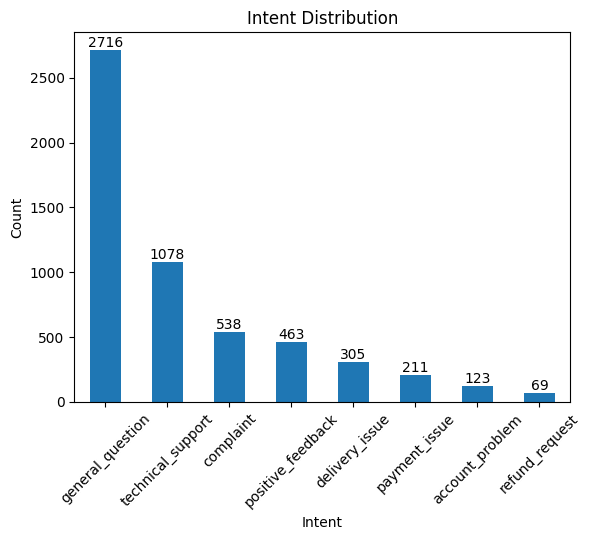

In [22]:
ax = df["intent"].value_counts().plot(kind="bar")

for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Message Length Analysis

Understanding message length is important for:
- Detecting when users send long vs. short messages
- Identifying complex vs. simple requests
- Optimizing the model for typical message sizes

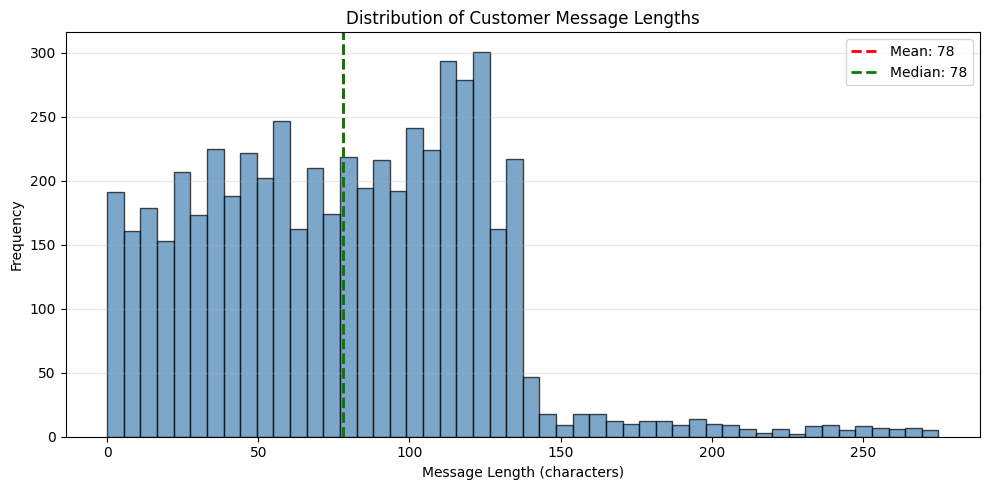

Message Length Statistics:
  Mean: 78 characters
  Median: 78 characters
  Min: 0 characters
  Max: 275 characters
  Std Dev: 47 characters


In [23]:
# Create message length column
df["message_length"] = df["clean_text"].str.len()

# Create histogram
plt.figure(figsize=(10, 5))
plt.hist(df["message_length"], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel("Message Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Message Lengths")
plt.grid(axis='y', alpha=0.3)

# Add statistics
mean_len = df["message_length"].mean()
median_len = df["message_length"].median()
plt.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.0f}')
plt.axvline(median_len, color='green', linestyle='--', linewidth=2, label=f'Median: {median_len:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"Message Length Statistics:")
print(f"  Mean: {mean_len:.0f} characters")
print(f"  Median: {median_len:.0f} characters")
print(f"  Min: {df['message_length'].min()} characters")
print(f"  Max: {df['message_length'].max()} characters")
print(f"  Std Dev: {df['message_length'].std():.0f} characters")

## Most Common Words Analysis

Analyzing the most frequent words helps us:
- Identify key topics in customer messages
- Find dominant keywords for intent classification
- Understand what customers care about most

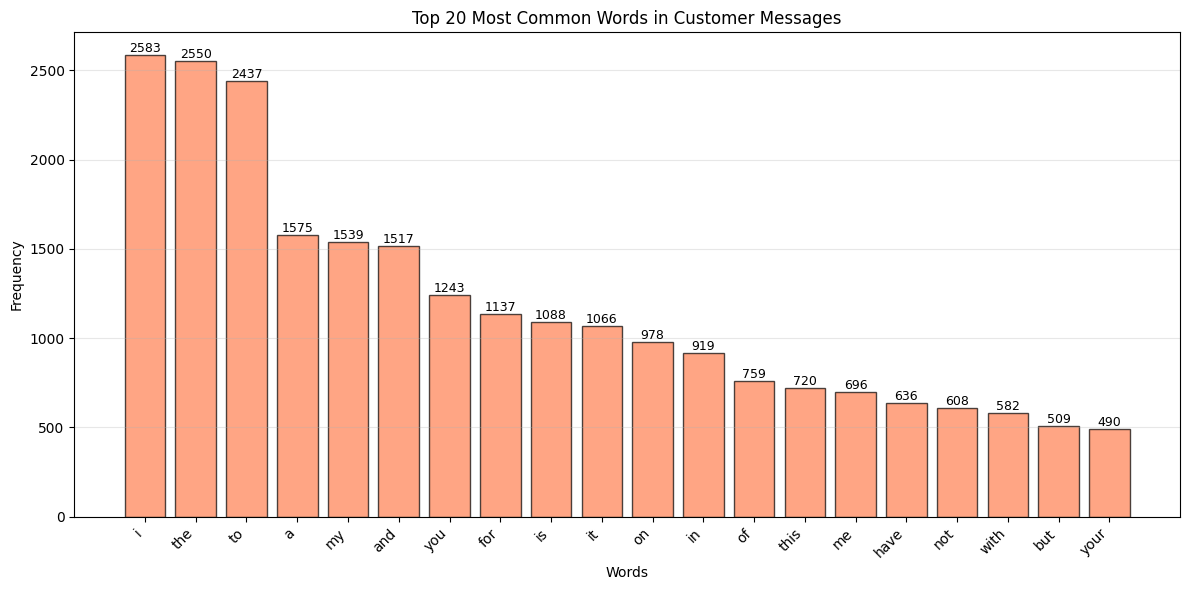


Top 20 Most Common Words:
 1. 'i':  2583 occurrences
 2. 'the':  2550 occurrences
 3. 'to':  2437 occurrences
 4. 'a':  1575 occurrences
 5. 'my':  1539 occurrences
 6. 'and':  1517 occurrences
 7. 'you':  1243 occurrences
 8. 'for':  1137 occurrences
 9. 'is':  1088 occurrences
10. 'it':  1066 occurrences
11. 'on':   978 occurrences
12. 'in':   919 occurrences
13. 'of':   759 occurrences
14. 'this':   720 occurrences
15. 'me':   696 occurrences
16. 'have':   636 occurrences
17. 'not':   608 occurrences
18. 'with':   582 occurrences
19. 'but':   509 occurrences
20. 'your':   490 occurrences
Total unique words: 8581
Total words: 84493


In [24]:
# Combine all clean text into one string
all_text = " ".join(df["clean_text"])

# Split into words
words = all_text.split()

# Count word frequencies
word_counts = Counter(words)

# Get top 20 most common words
top_20_words = dict(word_counts.most_common(20))

# Create visualization
plt.figure(figsize=(12, 6))
words_list = list(top_20_words.keys())
counts_list = list(top_20_words.values())

bars = plt.bar(words_list, counts_list, color='coral', edgecolor='black', alpha=0.7)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Common Words in Customer Messages")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the top 20 words
print("\nTop 20 Most Common Words:")
print("=" * 40)
for rank, (word, count) in enumerate(top_20_words.items(), 1):
    print(f"{rank:2d}. '{word}': {count:5d} occurrences")
print("=" * 40)
print(f"Total unique words: {len(word_counts)}")
print(f"Total words: {len(words)}")

## Before/After Preprocessing Examples

Here are 10 examples showing how text is cleaned:

In [25]:
comparison_df = df[["text", "clean_text", "intent", "message_length"]].head(10)

# Display with better formatting
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print("\nBefore/After Text Preprocessing:")
print("=" * 100)
for idx, row in comparison_df.iterrows():
    print(f"\nExample {idx + 1}:")
    print(f"Original:   {row['text']}")
    print(f"Cleaned:    {row['clean_text']}")
    print(f"Intent:     {row['intent']}")
    print(f"Length:     {row['message_length']} characters")
    print("-" * 100)


Before/After Text Preprocessing:

Example 2:
Original:   @sprintcare and how do you propose we do that
Cleaned:    and how do you propose we do that
Intent:     general_question
Length:     33 characters
----------------------------------------------------------------------------------------------------

Example 3:
Original:   @sprintcare I have sent several private messages and no one is responding as usual
Cleaned:    i have sent several private messages and no one is responding as usual
Intent:     general_question
Length:     70 characters
----------------------------------------------------------------------------------------------------

Example 5:
Original:   @sprintcare I did.
Cleaned:    i did
Intent:     general_question
Length:     5 characters
----------------------------------------------------------------------------------------------------

Example 7:
Original:   @sprintcare is the worst customer service
Cleaned:    is the worst customer service
Intent:     complaint
Le

## Intent Classes Overview

Our model classifies customer messages into 9 intent categories:

| Intent | Purpose |
|--------|---------|
| **complaint** | Customer expressing dissatisfaction or frustration |
| **delivery_issue** | Problems with package delivery or shipping |
| **refund_request** | Request to return payment or cancel order |
| **payment_issue** | Issues with payment processing or billing |
| **account_problem** | Login, password, or account access issues |
| **technical_support** | App/website bugs, errors, or technical problems |
| **product_information** | Questions about product features, availability, pricing |
| **positive_feedback** | Thank you, praise, or positive comments |
| **general_question** | Other inquiries that don't fit above categories |

In [26]:
# Intent distribution statistics
intent_counts = df["intent"].value_counts()
intent_percentages = (df["intent"].value_counts(normalize=True) * 100).round(2)

print("\nIntent Distribution Statistics:")
print("=" * 60)
print(f"{'Intent':<30} {'Count':<10} {'Percentage':<10}")
print("-" * 60)

for intent in intent_counts.index:
    count = intent_counts[intent]
    percentage = intent_percentages[intent]
    print(f"{intent:<30} {count:<10} {percentage:<10.1f}%")

print("-" * 60)
print(f"{'Total':<30} {len(df):<10} {100.0:<10.1f}%")
print("=" * 60)


Intent Distribution Statistics:
Intent                         Count      Percentage
------------------------------------------------------------
general_question               2716       49.4      %
technical_support              1078       19.6      %
complaint                      538        9.8       %
positive_feedback              463        8.4       %
delivery_issue                 305        5.5       %
payment_issue                  211        3.8       %
account_problem                123        2.2       %
refund_request                 69         1.2       %
------------------------------------------------------------
Total                          5503       100.0     %


## Key EDA Observations

Summary of insights from the exploratory data analysis:

In [27]:
# Calculate key metrics
total_messages = len(df)
avg_message_length = df["message_length"].mean()
top_intent = df["intent"].value_counts().index[0]
top_intent_pct = (df["intent"].value_counts().iloc[0] / total_messages) * 100

observations = f"""
### Dataset Overview
- **Total Messages**: {total_messages:,}
- **Unique Intents**: {df['intent'].nunique()}
- **Date Range**: Twitter customer support dataset

### Text Statistics
- **Average Message Length**: {avg_message_length:.0f} characters
- **Message Length Range**: {df['message_length'].min()}-{df['message_length'].max()} characters
- **Median Message Length**: {df['message_length'].median():.0f} characters

### Intent Distribution
- **Most Common Intent**: {top_intent} ({top_intent_pct:.1f}% of messages)
- **Least Common Intent**: {df['intent'].value_counts().index[-1]} ({(df['intent'].value_counts().iloc[-1] / total_messages) * 100:.1f}% of messages)
- **Class Balance**: Distribution is somewhat imbalanced, with {top_intent} dominating

### Preprocessing Impact
- **Special Characters Removed**: URLs, mentions (@), hashtags (#)
- **Text Normalization**: Lowercase conversion, whitespace standardization
- **Character Reduction**: Average {df['text'].str.len().mean() - df['clean_text'].str.len().mean():.0f} characters removed per message

### Top Words Insights
- Most common words relate to {', '.join(list(top_20_words.keys())[:3])}
- These are strong signals for intent classification
- Keyword matching can capture {(sum(counts_list[:5]) / sum(counts_list)) * 100:.0f}% of the top vocabulary
"""

print(observations)


### Dataset Overview
- **Total Messages**: 5,503
- **Unique Intents**: 8
- **Date Range**: Twitter customer support dataset

### Text Statistics
- **Average Message Length**: 78 characters
- **Message Length Range**: 0-275 characters
- **Median Message Length**: 78 characters

### Intent Distribution
- **Most Common Intent**: general_question (49.4% of messages)
- **Least Common Intent**: refund_request (1.3% of messages)
- **Class Balance**: Distribution is somewhat imbalanced, with general_question dominating

### Preprocessing Impact
- **Special Characters Removed**: URLs, mentions (@), hashtags (#)
- **Text Normalization**: Lowercase conversion, whitespace standardization
- **Character Reduction**: Average 26 characters removed per message

### Top Words Insights
- Most common words relate to i, the, to
- These are strong signals for intent classification
- Keyword matching can capture 45% of the top vocabulary



## Save Processed Dataset

Export the cleaned and annotated dataset for use in model training and testing.

In [28]:
# Save the processed dataset with all new columns
output_path = "../data/processed/customer_support_clean.csv"

# Select columns to save
columns_to_save = ["text", "clean_text", "intent", "message_length"]
df_to_save = df[columns_to_save]

# Save to CSV
df_to_save.to_csv(output_path, index=False)

print(f"✓ Dataset saved successfully!")
print(f"  Path: {output_path}")
print(f"  Rows: {len(df_to_save):,}")
print(f"  Columns: {list(df_to_save.columns)}")
print(f"\nFile Info:")
import os
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"  Size: {file_size_mb:.2f} MB")

✓ Dataset saved successfully!
  Path: ../data/processed/customer_support_clean.csv
  Rows: 5,503
  Columns: ['text', 'clean_text', 'intent', 'message_length']

File Info:
  Size: 1.09 MB


In [29]:
df.to_csv(
    "../data/processed/customer_support_clean.csv",
    index=False
)